In [34]:
import pandas as pd
from xgboost import XGBRegressor 
from sklearn.metrics import mean_squared_error
from math import sqrt


In [35]:
df = pd.read_csv('/home/purushottam/MACHINE LEARNING/TIME SERIES/DATASETS/monthly_champagne_sales.csv')

In [36]:
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month')
df = df.set_index('Month')

In [37]:
def time(df):
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    df['Quarter'] = df.index.quarter
    return df

def features(df):
    df['Lag 1'] = df['Sales'].shift(1)
    df['Lag 6'] = df['Sales'].shift(6)
    df['Lag 12'] = df['Sales'].shift(12)
    df['MA 6'] = df['Sales'].shift(1).rolling(6).mean()
    df['MA 12'] = df['Sales'].shift(1).rolling(12).mean()
    df['STD 6'] = df['Sales'].shift(1).rolling(6).std()
    df['STD 12'] = df['Sales'].shift(1).rolling(12).std()
    return df
    

In [38]:
train = df[(df.index >= '1964-01-01') & (df.index > '1969-12-01')]
val = df[(df.index >= '1969-12-01') & (df.index < '1971-01-01')]
test = df[(df.index >= '1971-01-01')  & (df.index <= '1972-09-01')]

In [39]:
train = time(train)
train = features(train)

val = time(val)
val = features(val)

test = time(test)
test = features(test)

train.dropna(inplace= True)
val.dropna(inplace= True)
test.dropna(inplace = True)

In [40]:
Features = ['Lag 1', 'Lag 6', 'Lag 12', 'MA 6', 'MA 12', 'STD 6', 'STD 12', 'Month', 'Year', 'Quarter']
Target = ['Sales']

x_train = train[Features]
y_train = train[Target]

x_val = val[Features]
y_Val = val[Target]

x_test = test[Features]
y_test = test[Target]

In [41]:
model = XGBRegressor(n_estimators = 1500, learning_rate = 0.005, max_depth = 5)



In [45]:
def validate(x_train, y_train, x_test, y_test):
    history_x = x_train.copy()
    history_y = y_train.copy()

    predictions = []

    for i in range(len(x_test)):
        model.fit(history_x, history_y)

        pred = model.predict(x_test.iloc[[i]])   
        predictions.append([0])

        history_x = pd.concat([x_train, x_test.iloc[[i]]])
        history_y = pd.concat([y_train, y_test.iloc[[i]]])

    error = sqrt(mean_squared_error(y_test, predictions))

    residuals = y_test.values - predictions
    
    return error, predictions, residuals 

In [46]:
mase, predictions, residuals = validate(x_train, y_train, x_test, y_test)

In [47]:
print (mase)

4472.543931838146


In [31]:
df['Persistence'] = df['Sales'].shift(1)
df.dropna(inplace= True)
mae_persistence = mean_absolute_error(df['Sales'].values, df['Persistence'].values)
print (mae_persistence)

1737.3725490196077


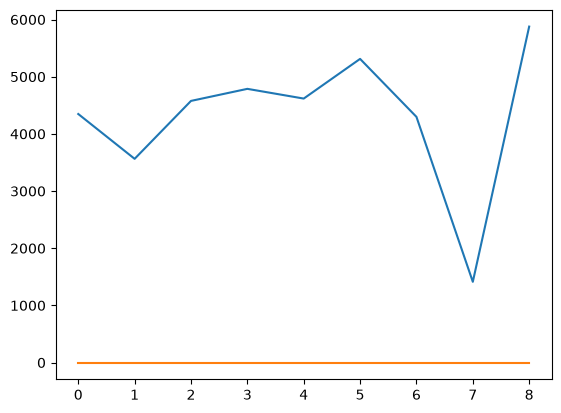

In [48]:
import matplotlib.pyplot as plt

plt.plot(y_test.values)
plt.plot(predictions)

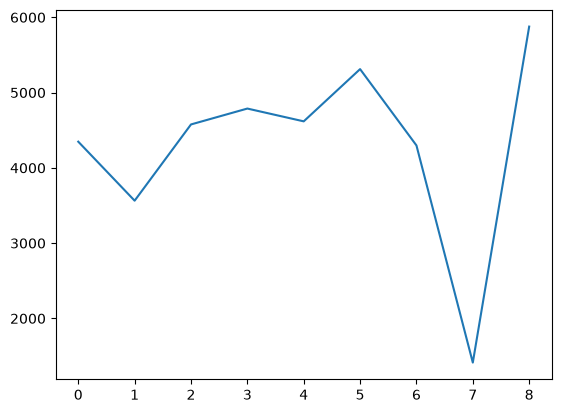

In [49]:
plt.plot(residuals)

In [50]:
residuals.mean()

np.float64(4310.555555555556)